In [20]:
"""
Module for handling Simple Stellar Population (SSP) data.

This module provides utilities to retrieve and store SSP data using 
FSPS and JAX for efficient operations. It defines a frozen dataclass 
for storing SSP-related data, as well as functions for data collection.

Globals:
--------
DEFAULT_SSP_BNAME : str
    The default file name for the SSP data.
"""

import h5py
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from dataclasses import dataclass
import jax
import jax.numpy as jnp
import tqdm
import blackjax
from functools import partial
from jax import jit, grad

import astropy.constants as const

import matplotlib.pyplot as plt
import fsps


tiny_number = 1e-70
rng = np.random.default_rng(13)

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

#from project_utils import open_pickled_file, setup_matplotlib_styles

#setup_matplotlib_styles()
#colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
#sns.set_palette(colors)

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 9     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)
zh = jnp.linspace(0.0002, 0.2, len(tau))

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

path_figs = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/presentation'

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

def gaussian_burst(center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)



sfr_old = gaussian_burst(center_tau=12.0, width_tau=1.0, amp=1.0)


csp = CSPBasis(ssp_data, dusty=False, add_neb=False)
csp.add_sfh(sfr_old, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


# Generate the Observation and set up Hyperparameters

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


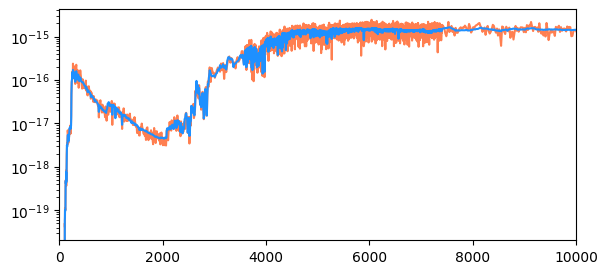

In [21]:
csp = CSPBasis(ssp_data, dusty=False, add_neb=False)
csp.add_sfh(sfr_old, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()

rng_key = jax.random.PRNGKey(42)

key, rng_key = jax.random.split(rng_key)
sigma = 0.2 * spec  # relative noise level
noise = sigma * jax.random.normal(key, shape=spec.shape)
spectrum_obs = spec + noise


plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), label='SFH', color='dodgerblue')
plt.plot(csp.wave, fnu2flam(csp.wave, spectrum_obs*1e-23*3631), label='Observed', color='coral', zorder = 0)
plt.xlim(0, 10000)
plt.yscale('log')

# Generate the Model for the Likelihood Function

In [31]:
csp = CSPBasis(ssp_data)

sfh = jnp.ones_like(tau)  # Initial guess for SFH
zh = jnp.ones_like(tau) * csp.zlegend[2]
csp.add_sfh(sfh=sfh, lookback_time=tau) #need to set sfh_times 
model = partial(csp.get_spectrum_direct_dustfree)  # csp is now static

print(model)

lookback time
functools.partial(<bound method CSPBasis.get_spectrum_direct_dustfree of <CSPBasis Object>
-----------------------------------
Universe Age (tuniv): 13.8 Gyr
Tiny Log Time (tiny_logt): -10
Number of SSP Ages: 108
Number of SSP Metallicities: 12
Wavelength Range: 91.0 - 100000000.0 Å
Star Formation History:
  SFH Times (lookback): [1.3790000e+10 1.2066250e+10 1.0342500e+10 8.6187500e+09 6.8950001e+09
 5.1712502e+09 3.4475003e+09 1.7237501e+09 0.0000000e+00]
  SFH Values: [1. 1. 1. 1. 1. 1. 1. 1. 1.]
Spectrum: Not computed yet
Dust Model: Dust Model Configuration
Number of bins          : 2
Bin edges (Gyr)         : 
    [ -inf -1.97]
    [-1.97   inf]
Dust laws               : powerlaw, kriek_conroy
Dust parameters        : {'tau_pow': 'Optical depth at reference wavelength (e.g., 1500 Å)', 'alpha': 'Slope of attenuation power law (typically negative)'}, {'tau_kc': 'Amplitude of attenuation at 5500 Å', 'dust_index': 'Power-law slope around the Calzetti curve'}
Diffuse dust

# Check Grad and JIT

In [32]:
model = jax.jit(model)
spectrum = model(sfh, zh)

# grad also works (with respect to sfh, for example)
grad_spectrum = grad(lambda sfh: jnp.sum(model(sfh, zh)))(sfh)
print(spectrum)
print('JIT and grad work!')

[3.8962530e-10 4.4882822e-10 5.0387167e-10 ... 8.0529268e-13 7.9051387e-13
 7.7601321e-13]
JIT and grad work!


# Set Up Likelihood Function

In [27]:

def unpack_params(params_flat, n_bins):
    sfh = jnp.array([params_flat[f"sfh_{i}"] for i in range(n_bins)])
    zh  = jnp.array([params_flat[f"zh_{i}"]  for i in range(n_bins)])
    sigma = jnp.array(params_flat["sigma"])
    return sfh, zh, sigma

def loglikelihood_fn(params_flat):
    sfh, zh, sigma = unpack_params(params_flat, n_bins=N_T)
    mu = model(sfh, zh)
    print(mu)
    cov = sigma ** 2
    lgl = jax.scipy.stats.multivariate_normal.logpdf(spectrum_obs, mu, cov)
    return lgl

# Set up Prior Function


In [28]:
from blackjax.ns.utils import uniform_prior
prior_bounds = {
    'sfh_0': (0.001, 12.0),
    'sfh_1': (0.001, 12.0),
    'sfh_2': (0.001, 12.0),
    'zh_0': (5e-5, 0.02),
    'zh_1': (5e-5, 0.02),
    'zh_2': (5e-5, 0.02),
    'sigma': (1e-7, 1e-5),
}

prior_bounds = {**{f"sfh_{i}": (0.0, 10.0) for i in range(N_T)},
                **{f"zh_{i}": (5e-5, 0.02) for i in range(N_T)},
                "sigma": (1e-7, 1e-5)}


#Define hyperparamters for rfitting:
rng_key = jax.random.PRNGKey(0)
num_dims = N_T * 2 + 1 #star formation history, metallicity history and sigma
num_live = 1000
num_inner_steps = num_dims * 5
num_delete = num_live // 2

rng_key, prior_key = jax.random.split(rng_key)
particles, logprior_fn = uniform_prior(prior_key, num_live, prior_bounds)


# Test if the likelihood function works

In [29]:
params_test = {'sfh_0': jnp.array([6.89615003, 3]),
    'sfh_1': jnp.array([2.78799016, 4]),
    'sfh_2': jnp.array([2.02322524, 5]),
    'sfh_3': jnp.array([2.78799016, 4]),
    'sfh_4': jnp.array([2.02322524, 5]),
    'sfh_5': jnp.array([2.78799016, 4]),
    'sfh_6': jnp.array([2.02322524, 5]),
    'sfh_7': jnp.array([2.78799016, 4]),
    'sfh_8': jnp.array([2.02322524, 5]),
    'sigma': jnp.array([0.0059143, 0.001]),
    'zh_0': jnp.array([0.00010885, 0.00044]),
    'zh_1': jnp.array([0.0002968, 0.0008]),
    'zh_2': jnp.array([0.0001728, 0.0009]),
    'zh_3': jnp.array([0.00010885, 0.00044]),
    'zh_4': jnp.array([0.0002968, 0.0008]),
    'zh_5': jnp.array([0.00010885, 0.00044]),
    'zh_6': jnp.array([0.0002968, 0.0008]),
    'zh_7': jnp.array([0.00010885, 0.00044]),
    'zh_8': jnp.array([0.0002968, 0.0008])
}

lls = jax.vmap(loglikelihood_fn)(params_test)
print(f"Log-likelihoods for test parameters: {lls}")

Traced<ShapedArray(float32[5994])>with<BatchTrace> with
  val = Array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
  batch_dim = 0
Log-likelihoods for test parameters: [nan nan]


# Nested Sampler ---- What do I have to do different here, Harvey, to implement HMC?

In [10]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
    )

init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)
live = init_fn(particles)

# And this is the part that does not work.

In [ ]:
dead = []
print('Starting sampling...')

with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        print(f"Current logZ: {live.logZ_live - live.logZ}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

dead = blackjax.ns.utils.finalise(live, dead)

print('Sampling completed.')